In [1]:
# batch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATASETS = ['Stephenson', 'Brain-ISSAAC', 'TEA-3D']
SEEDS = [4055, 2120, 4519, 3868, 8785, 234, 45346, 123, 567, 5678]
results_batch = pd.DataFrame()
for dataset in DATASETS:
    for seed in SEEDS:
        try:
            result = pd.read_csv(f'../Results/{dataset}/{seed}_batch_metrics.csv')
            result_info = pd.DataFrame([[dataset, seed]], columns=['Dataset', 'Seed'])
            result = pd.concat([result, result_info], axis=1)
            results_batch = pd.concat([results_batch, result], axis=0, ignore_index=True)
        except FileNotFoundError:
            print(f"File not found for dataset: {dataset}, seed: {seed}")

In [2]:
results_bio_seeds = pd.DataFrame()
for dataset in DATASETS:
    for seed in SEEDS:
        try:
            result = pd.read_csv(f'../Results/{dataset}/{seed}_bio_metrics.csv', index_col=0)
            result.rename(columns={
                                'normalized_mutual_info': 'NMI',
                                'adjusted_rand_index': 'ARI',
                                'fowlkes_mallows': 'FMI',
                            }, inplace=True)
            result.reset_index(drop=True, inplace=True)
            result = pd.DataFrame([result.median()])
            result['Dataset'] = dataset
            result['Seed'] = seed
            results_bio_seeds = pd.concat([results_bio_seeds, result], axis=0, ignore_index=True)
        except FileNotFoundError:
            print(f"File not found for dataset: {dataset}, seed: {seed}")


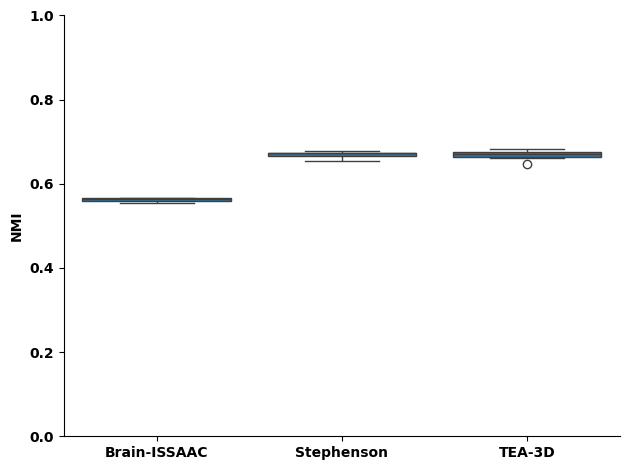

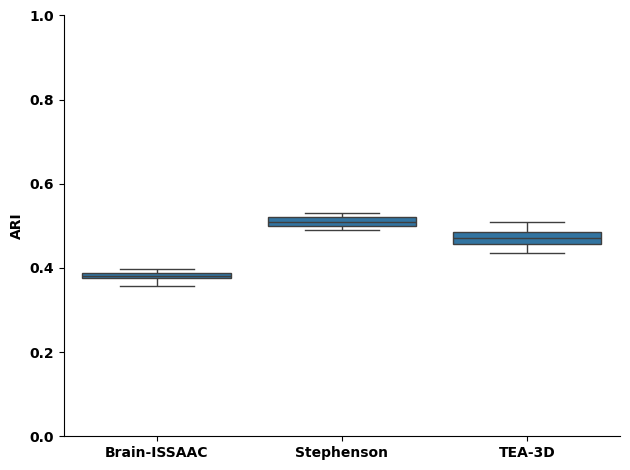

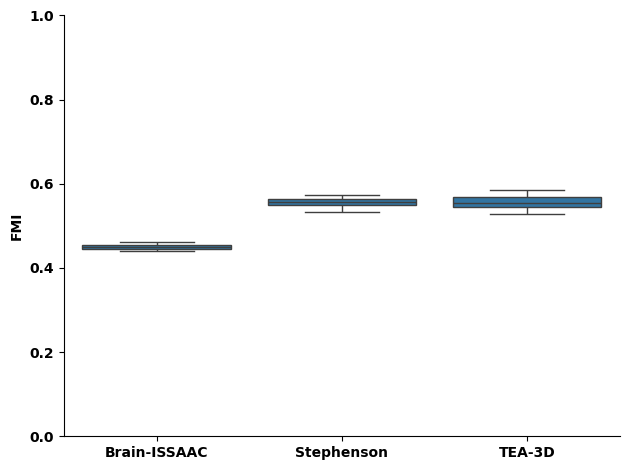

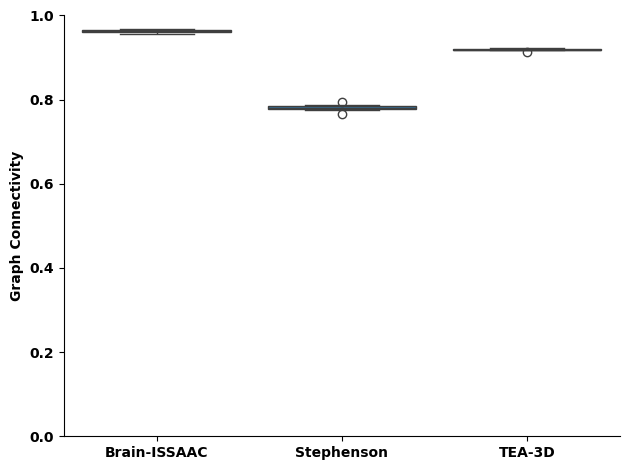

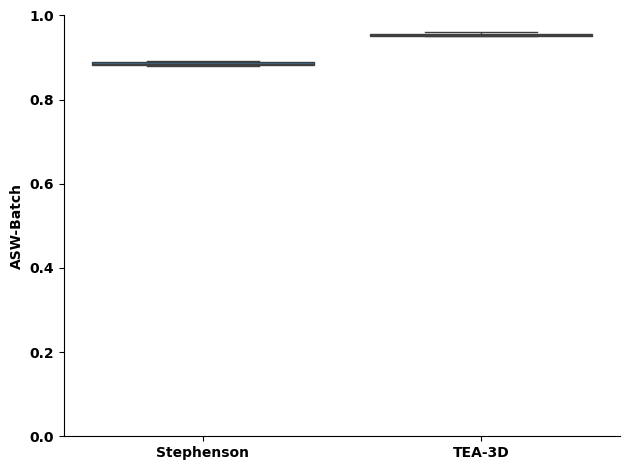

In [3]:
# final datasets
order = ['Brain-ISSAAC', 'Stephenson', 'TEA-3D']
for val in ['NMI', 'ARI', 'FMI']:
    # plt.figure(figsize=(12, 6))
    sns.boxplot(x='Dataset', y=val, data=results_bio_seeds, order=order)
    sns.despine(top=True, right=True)
    plt.ylabel(val, fontweight="bold")
    plt.xlabel("")
    plt.xticks(fontweight="bold")
    plt.yticks(fontweight="bold")

    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(f'./Results/{val}_boxplot.png', dpi=300)
    plt.show()

for val in ['Graph Connectivity', 'ASW-Batch']:
    if val == 'ASW-Batch':
        order = ['Stephenson', 'TEA-3D']
    sns.boxplot(x='Dataset', y=val, data=results_batch, order=order)
    sns.despine(top=True, right=True)
    plt.ylabel(val, fontweight="bold")
    plt.xlabel("")
    plt.xticks(fontweight="bold")
    plt.yticks(fontweight="bold")

    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(f'./Results/{val}_boxplot.png', dpi=300)
    plt.show()

In [4]:
data = pd.merge(results_bio_seeds, results_batch, on = ["Dataset", 'Seed']).groupby("Dataset")[["NMI","ARI","FMI", "ASW-Batch","Graph Connectivity"]].agg(['mean', 'std']).round(3)
data_mean = pd.merge(results_bio_seeds, results_batch, on = ["Dataset", 'Seed']).groupby("Dataset")[["NMI","ARI","FMI", "ASW-Batch","Graph Connectivity"]].mean()
data_mean.to_csv("./Results/metrics_mean.csv")
data_std = pd.merge(results_bio_seeds, results_batch, on = ["Dataset", 'Seed']).groupby("Dataset")[["NMI","ARI","FMI", "ASW-Batch","Graph Connectivity"]].std()
data_std.to_csv("./Results/metrics_std.csv")
data

NMI           ARI           FMI        ASW-Batch         \
               mean    std   mean    std   mean    std      mean    std   
Dataset                                                                   
Brain-ISSAAC  0.562  0.004  0.381  0.012  0.450  0.007       NaN    NaN   
Stephenson    0.670  0.007  0.510  0.014  0.555  0.013     0.886  0.004   
TEA-3D        0.669  0.011  0.473  0.024  0.557  0.019     0.954  0.003   

             Graph Connectivity         
                           mean    std  
Dataset                                 
Brain-ISSAAC              0.962  0.004  
Stephenson                0.781  0.007  
TEA-3D                    0.919  0.003

In [5]:
result = pd.DataFrame(index=data.index)

for metric in data.columns.levels[0]:
    result[metric] = (
        data[(metric, "mean")].round(3).astype(str)
        + " ± "
        + data[(metric, "std")].round(3).astype(str)
    )

# Handle NaN values
result = result.replace(r"nan ± nan", "", regex=True)

print(result)

                        NMI            ARI            FMI      ASW-Batch  \
Dataset                                                                    
Brain-ISSAAC  0.562 ± 0.004  0.381 ± 0.012   0.45 ± 0.007                  
Stephenson     0.67 ± 0.007   0.51 ± 0.014  0.555 ± 0.013  0.886 ± 0.004   
TEA-3D        0.669 ± 0.011  0.473 ± 0.024  0.557 ± 0.019  0.954 ± 0.003   

             Graph Connectivity  
Dataset                          
Brain-ISSAAC      0.962 ± 0.004  
Stephenson        0.781 ± 0.007  
TEA-3D            0.919 ± 0.003  


In [15]:
result.loc[["Brain-ISSAAC", "Stephenson", "TEA-3D"]]

,NMI,ARI,FMI,ASW-Batch,Graph Connectivity
Dataset,,,,,
Brain-ISSAAC,0.562 ± 0.004,0.381 ± 0.012,0.45 ± 0.007,,0.962 ± 0.004
Stephenson,0.67 ± 0.007,0.51 ± 0.014,0.555 ± 0.013,0.886 ± 0.004,0.781 ± 0.007
TEA-3D,0.669 ± 0.011,0.473 ± 0.024,0.557 ± 0.019,0.954 ± 0.003,0.919 ± 0.003
